--- 2.4: Supervised Learning - Classification (Decision Trees) ---

--- Applying Decision Tree Classifier ---

Decision Tree model training complete.

--- Decision Tree Model Evaluation on Test Data ---

Accuracy (Decision Tree): 0.53

Confusion Matrix (Decision Tree):
 [[8 7]
 [7 8]]

Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.53      0.53      0.53        15
           1       0.53      0.53      0.53        15

    accuracy                           0.53        30
   macro avg       0.53      0.53      0.53        30
weighted avg       0.53      0.53      0.53        30


--- Feature Importances (Decision Tree) ---
          Feature  Importance
0     Study_Hours    0.553022
1  Previous_Score    0.446978


/Volumes/Extra_Memory/Learning/Anaconda_Installation/anaconda3/envs/my_da_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


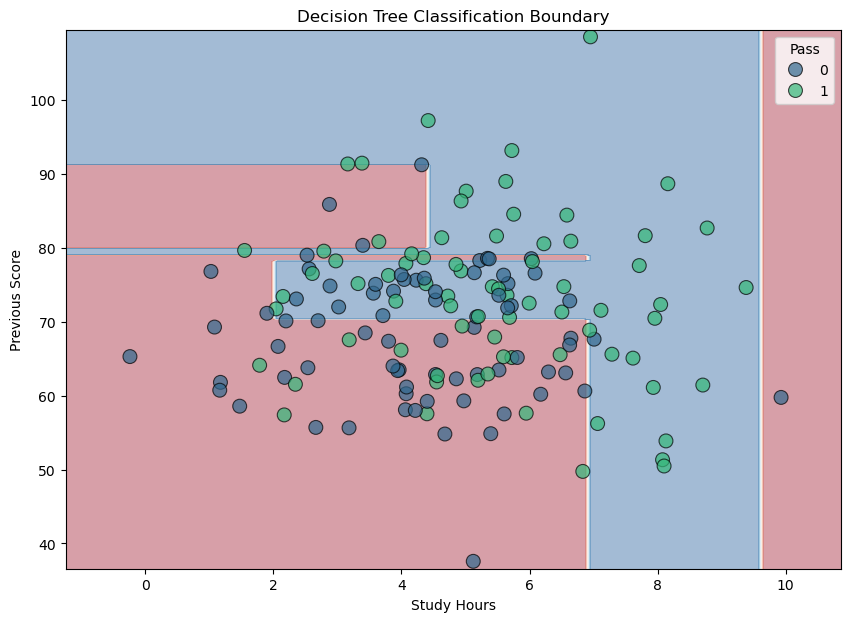


Summary: You've implemented a Decision Tree for classification!
You've seen its interpretability through feature importances and its ability to create non-linear decision boundaries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier # Our new classification algorithm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Evaluation metrics

# --- Re-generate the same synthetic data for consistency ---
np.random.seed(42)
num_samples = 150
study_hours = np.random.normal(loc=5, scale=2, size=num_samples)
previous_score = np.random.normal(loc=70, scale=10, size=num_samples)
probability_of_pass = 1 / (1 + np.exp(-(0.5 * study_hours + 0.1 * previous_score - 9)))
is_pass = (probability_of_pass > np.random.rand(num_samples)).astype(int)

df_clf = pd.DataFrame({
    'Study_Hours': study_hours,
    'Previous_Score': previous_score,
    'Pass': is_pass
})

X = df_clf[['Study_Hours', 'Previous_Score']]
y = df_clf['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 2.4: Supervised Learning - Classification (Decision Trees) ---")
print("\n--- Applying Decision Tree Classifier ---")

# Step 3 & 4: Model Selection and Training
# Instantiate the Decision Tree Classifier
# random_state ensures reproducibility of the tree's split decisions
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5) # max_depth limits how deep the tree can grow
dt_model.fit(X_train, y_train) # Train the model

print("\nDecision Tree model training complete.")

# Step 5: Model Prediction
y_pred_dt = dt_model.predict(X_test)

# Step 6: Model Evaluation
print("\n--- Decision Tree Model Evaluation on Test Data ---")
accuracy_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cr_dt = classification_report(y_test, y_pred_dt)

print(f"\nAccuracy (Decision Tree): {accuracy_dt:.2f}")
print("\nConfusion Matrix (Decision Tree):\n", cm_dt)
print("\nClassification Report (Decision Tree):\n", cr_dt)

# --- New Concept for Trees: Feature Importance ---
# Decision Trees can tell us which features were most influential in making decisions.
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importances (Decision Tree) ---")
print(feature_importances)

# Optional: Visualize the Decision Boundary (More complex, but powerful)
# This part helps understand how the tree splits the space.
# We'll create a meshgrid to plot the decision boundary
x_min, x_max = X['Study_Hours'].min() - 1, X['Study_Hours'].max() + 1
y_min, y_max = X['Previous_Score'].min() - 1, X['Previous_Score'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on the meshgrid points
Z = dt_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)
# Plot the actual data points
sns.scatterplot(x='Study_Hours', y='Previous_Score', hue='Pass', data=df_clf, palette='viridis', s=100, alpha=0.7, edgecolor='k')
plt.title('Decision Tree Classification Boundary')
plt.xlabel('Study Hours')
plt.ylabel('Previous Score')
plt.show()

print("\nSummary: You've implemented a Decision Tree for classification!")
print("You've seen its interpretability through feature importances and its ability to create non-linear decision boundaries.")